--- TASK 1: Dataset Exploration ---

First 5 samples:


,variance,skewness,curtosis,entropy,class
0,3.62160,8.6661,-2.8073,-0.44699,0
1,4.54590,8.1674,-2.4586,-1.46210,0
2,3.86600,-2.6383,1.9242,0.10645,0
3,3.45660,9.5228,-4.0112,-3.59440,0
4,0.32924,-4.4552,4.5718,-0.98880,0



Dataset Dimensions: (1372, 5)
Missing Values:
 variance    0
skewness    0
curtosis    0
entropy     0
class       0
dtype: int64

Descriptive Statistics:


,variance,skewness,curtosis,entropy,class
count,1372.000000,1372.000000,1372.000000,1372.000000,1372.000000
mean,0.433735,1.922353,1.397627,-1.191657,0.444606
std,2.842763,5.869047,4.310030,2.101013,0.497103
min,-7.042100,-13.773100,-5.286100,-8.548200,0.000000
25%,-1.773000,-1.708200,-1.574975,-2.413450,0.000000
50%,0.496180,2.319650,0.616630,-0.586650,0.000000
75%,2.821475,6.814625,3.179250,0.394810,1.000000
max,6.824800,12.951600,17.927400,2.449500,1.000000



--- Generating EDA Plots ---


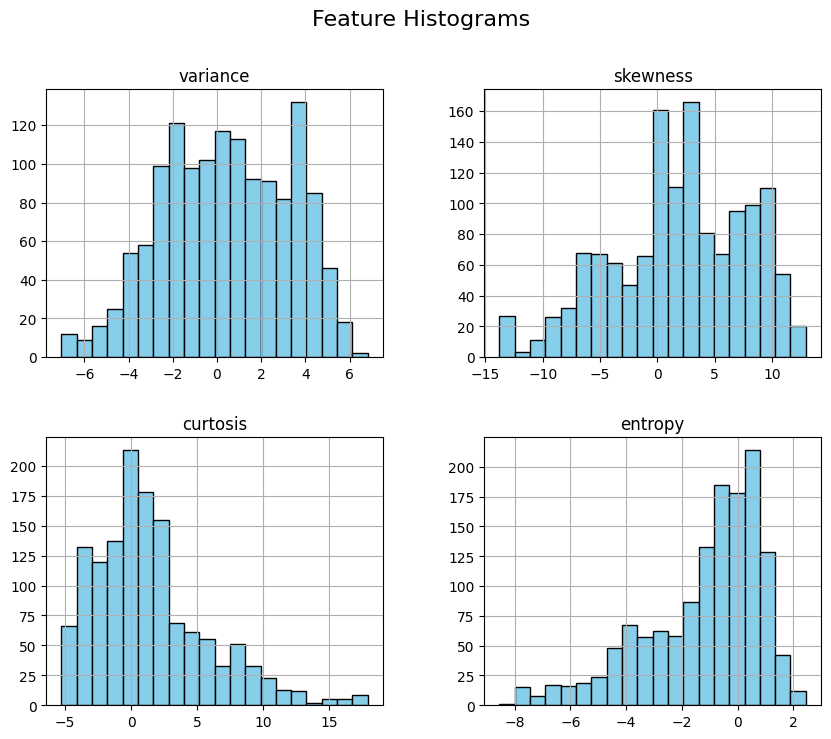

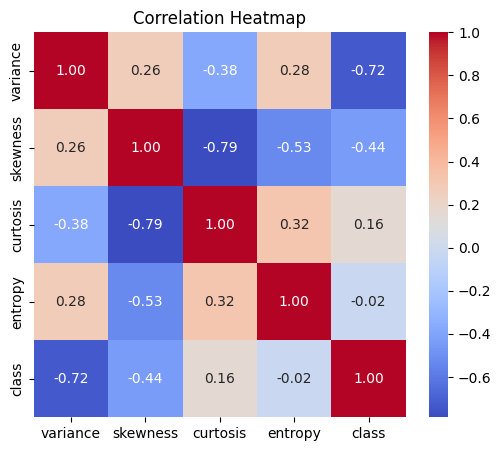

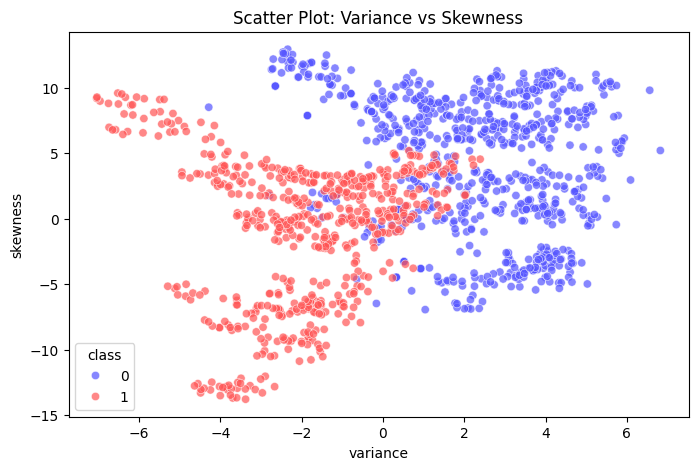

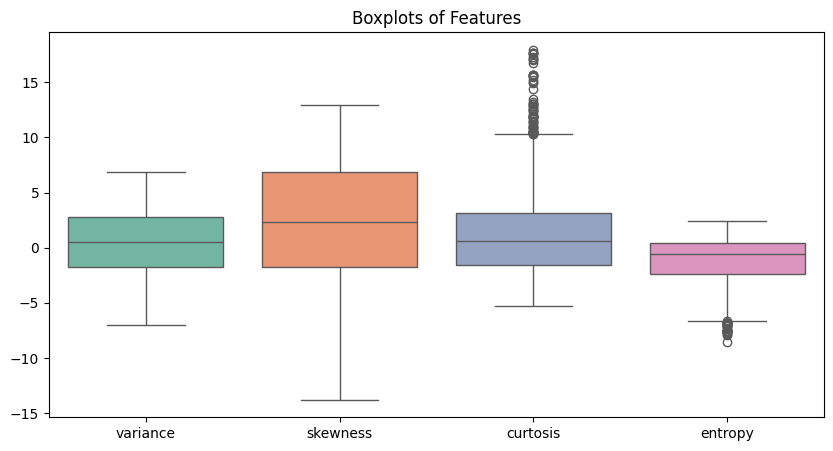

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.linear_model import Perceptron as SklearnPerceptron

# --- TASK 1: Dataset Exploration ---
print("--- TASK 1: Dataset Exploration ---")

# The dataset is hosted on the UCI repository
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00267/data_banknote_authentication.txt"
col_names = ['variance', 'skewness', 'curtosis', 'entropy', 'class']
df = pd.read_csv(url, names=col_names)

print("\nFirst 5 samples:")
display(df.head())

print("\nDataset Dimensions:", df.shape)
print("Missing Values:\n", df.isnull().sum())

print("\nDescriptive Statistics:")
display(df.describe())

# --- TASK 2: Exploratory Data Analysis & Mandatory Plots ---
print("\n--- Generating EDA Plots ---")

# 1. Feature Histograms
df.drop('class', axis=1).hist(figsize=(10, 8), bins=20, color='skyblue', edgecolor='black')
plt.suptitle("Feature Histograms", fontsize=16)
plt.show()
# Inference: Shows the distribution of features; helps identify skewness (e.g., entropy is heavily left-skewed) and potential outliers.

# 2. Correlation Heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()
# Inference: Reveals relationships between features; variance and skewness have the strongest negative correlation with the target class.

# 3. Scatter Plot (Variance vs Skewness colored by class)
plt.figure(figsize=(8, 5))
sns.scatterplot(x='variance', y='skewness', hue='class', data=df, palette='seismic', alpha=0.7)
plt.title("Scatter Plot: Variance vs Skewness")
plt.show()
# Inference: The classes (0 and 1) show distinct clusters, indicating they are approximately linearly separable using these features.

# Boxplots for outlier detection
plt.figure(figsize=(10, 5))
sns.boxplot(data=df.drop('class', axis=1), palette='Set2')
plt.title("Boxplots of Features")
plt.show()

In [2]:
# --- TASK 3: Data Preprocessing ---
X = df.drop('class', axis=1).values
y = df['class'].values

# Split into Training (80%) and Testing (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Normalize numerical features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# --- TASK 4: Perceptron Implementation ---
class SingleLayerPerceptron:
    def __init__(self, learning_rate=0.01, epochs=50):
        self.lr = learning_rate
        self.epochs = epochs
        self.weights = None
        self.bias = None
        self.error_history = []
        self.weight_history = []
        self.bias_history = []

    def _step_activation(self, z):
        """Step Activation Function: returns 1 if z >= 0 else 0"""
        return np.where(z >= 0, 1, 0)

    def fit(self, X, y, verbose=False):
        n_samples, n_features = X.shape
        # Weight and Bias Initialization
        self.weights = np.zeros(n_features)
        self.bias = 0.0

        for epoch in range(self.epochs):
            errors = 0
            for idx, x_i in enumerate(X):
                # Forward Propagation
                z = np.dot(x_i, self.weights) + self.bias
                y_pred = self._step_activation(z)

                # Update Rule
                update = self.lr * (y[idx] - y_pred)
                self.weights += update * x_i
                self.bias += update

                if update != 0.0:
                    errors += 1

            # Track history for plotting
            self.error_history.append(errors)
            self.weight_history.append(self.weights.copy())
            self.bias_history.append(self.bias)

            if verbose and (epoch % 10 == 0 or epoch == self.epochs - 1):
                print(f"Epoch {epoch+1}/{self.epochs} | Errors: {errors} | Weights: {self.weights} | Bias: {self.bias:.4f}")

        return self

    def predict(self, X):
        z = np.dot(X, self.weights) + self.bias
        return self._step_activation(z)

--- TASK 5: Training Custom Perceptron ---
Epoch 1/50 | Errors: 51 | Weights: [-0.06024909 -0.08407687 -0.06300015  0.00226864] | Bias: -0.0300
Epoch 11/50 | Errors: 18 | Weights: [-0.1252433  -0.16601169 -0.12954185 -0.00095055] | Bias: -0.0600
Epoch 21/50 | Errors: 12 | Weights: [-0.14654583 -0.19533693 -0.1743069  -0.01238284] | Bias: -0.0800
Epoch 31/50 | Errors: 14 | Weights: [-0.17620384 -0.20417715 -0.18571586 -0.02623563] | Bias: -0.0900
Epoch 41/50 | Errors: 17 | Weights: [-0.18332655 -0.22042891 -0.18926762 -0.00269678] | Bias: -0.1000
Epoch 50/50 | Errors: 16 | Weights: [-0.20404783 -0.22175178 -0.19953304 -0.02255425] | Bias: -0.0900

--- TASK 6: Model Evaluation ---
Accuracy:  0.9818
Precision: 0.9606
Recall:    1.0000
F1-score:  0.9799
Scikit-learn Perceptron Accuracy: 0.9673

--- Generating Model Evolution Plots ---


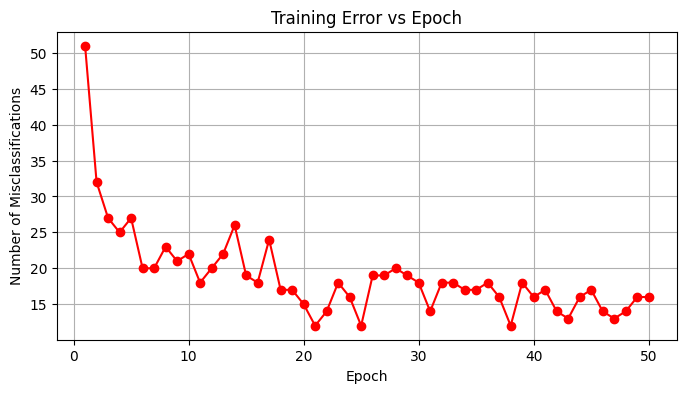

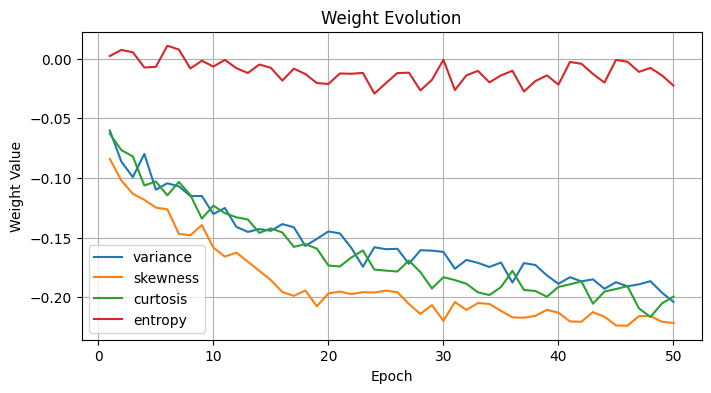

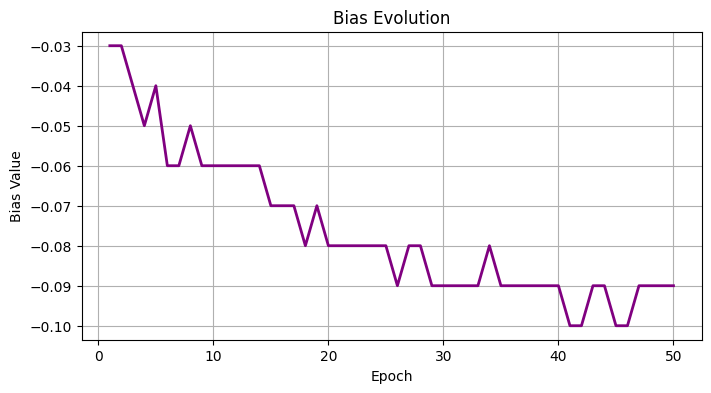

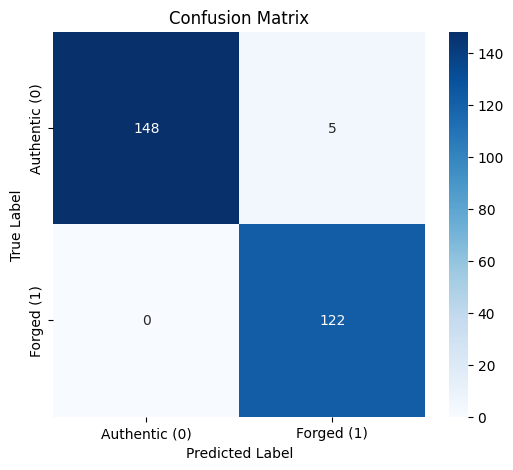

In [3]:
# --- TASK 5: Model Training ---
print("--- TASK 5: Training Custom Perceptron ---")
perceptron = SingleLayerPerceptron(learning_rate=0.01, epochs=50)
perceptron.fit(X_train_scaled, y_train, verbose=True)

# --- TASK 6: Model Evaluation ---
print("\n--- TASK 6: Model Evaluation ---")
y_pred = perceptron.predict(X_test_scaled)

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1-score:  {f1:.4f}")

# Compare with Scikit-learn's Perceptron
sk_perceptron = SklearnPerceptron(eta0=0.01, max_iter=50, random_state=42)
sk_perceptron.fit(X_train_scaled, y_train)
sk_pred = sk_perceptron.predict(X_test_scaled)
print(f"Scikit-learn Perceptron Accuracy: {accuracy_score(y_test, sk_pred):.4f}")

# --- Mandatory Plots 4, 5, 6, 7 ---
print("\n--- Generating Model Evolution Plots ---")

# 4. Training Error vs Epoch
plt.figure(figsize=(8, 4))
plt.plot(range(1, perceptron.epochs + 1), perceptron.error_history, marker='o', color='red')
plt.title("Training Error vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Number of Misclassifications")
plt.grid(True)
plt.show()
# Inference: The number of misclassifications decreases and plateaus near zero, verifying the convergence of the perceptron algorithm.

# 5. Weight Evolution
weight_hist_df = pd.DataFrame(perceptron.weight_history, columns=col_names[:-1])
plt.figure(figsize=(8, 4))
for col in weight_hist_df.columns:
    plt.plot(range(1, perceptron.epochs + 1), weight_hist_df[col], label=col)
plt.title("Weight Evolution")
plt.xlabel("Epoch")
plt.ylabel("Weight Value")
plt.legend()
plt.grid(True)
plt.show()
# Inference: The weights fluctuate initially but stabilize as the model learns the decision boundary parameters.

# 6. Bias Evolution
plt.figure(figsize=(8, 4))
plt.plot(range(1, perceptron.epochs + 1), perceptron.bias_history, color='purple', linewidth=2)
plt.title("Bias Evolution")
plt.xlabel("Epoch")
plt.ylabel("Bias Value")
plt.grid(True)
plt.show()
# Inference: The bias term shifts the decision boundary from the origin and stabilizes concurrently with the weights.

# 7. Confusion Matrix
plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Authentic (0)', 'Forged (1)'], yticklabels=['Authentic (0)', 'Forged (1)'])
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()
# Inference: The high values on the main diagonal (TP and TN) and low off-diagonal values (FP and FN) confirm exceptional classification performance.

--- Learning Rate Comparison ---


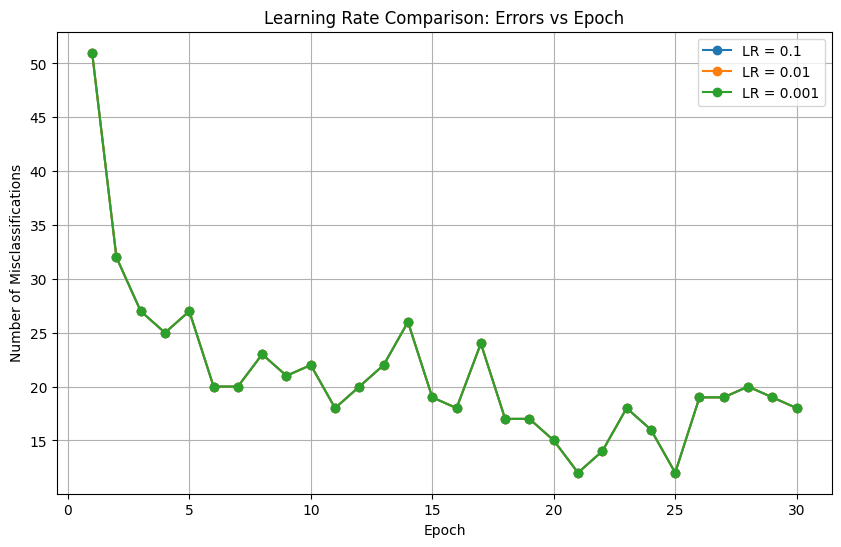

In [4]:
# --- TASK 7: Learning Rate Comparison ---
print("--- Learning Rate Comparison ---")
learning_rates = [0.1, 0.01, 0.001]
histories = {}

for lr in learning_rates:
    p = SingleLayerPerceptron(learning_rate=lr, epochs=30)
    p.fit(X_train_scaled, y_train, verbose=False)
    histories[lr] = p.error_history

# 8. Learning Rate Comparison Plot
plt.figure(figsize=(10, 6))
for lr, errors in histories.items():
    plt.plot(range(1, 31), errors, marker='o', label=f'LR = {lr}')
plt.title("Learning Rate Comparison: Errors vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Number of Misclassifications")
plt.legend()
plt.grid(True)
plt.show()
# Inference: Higher learning rates take larger steps and may oscillate slightly, whereas lower learning rates update parameters more smoothly but may require more epochs to converge.